# Anomaly Detection on Soil Moisture Sensor Data
## Shallot (*Allium cepa var. aggregatum*) Cultivation – ESP32 IoT System

Comparative anomaly detection pipeline

**Methods compared:**
- **Statistical:** Hampel Filter (sliding window + MAD)
- **Machine Learning:** Isolation Forest

**Pipeline stages:**
1. Data Loading & Parsing (Firebase JSON from ESP32)
2. Data Preparation (Missing Value Handling → Z-score Normalization → Time-Series Windowing)
3. Synthetic Anomaly Injection (Spike, Drop, Drift, Stuck)
4. Anomaly Detection (Hampel Filter & Isolation Forest)
5. Performance Evaluation (Precision, Recall, F1-Score, ROC-AUC, PR-AUC)


### Import Libraries

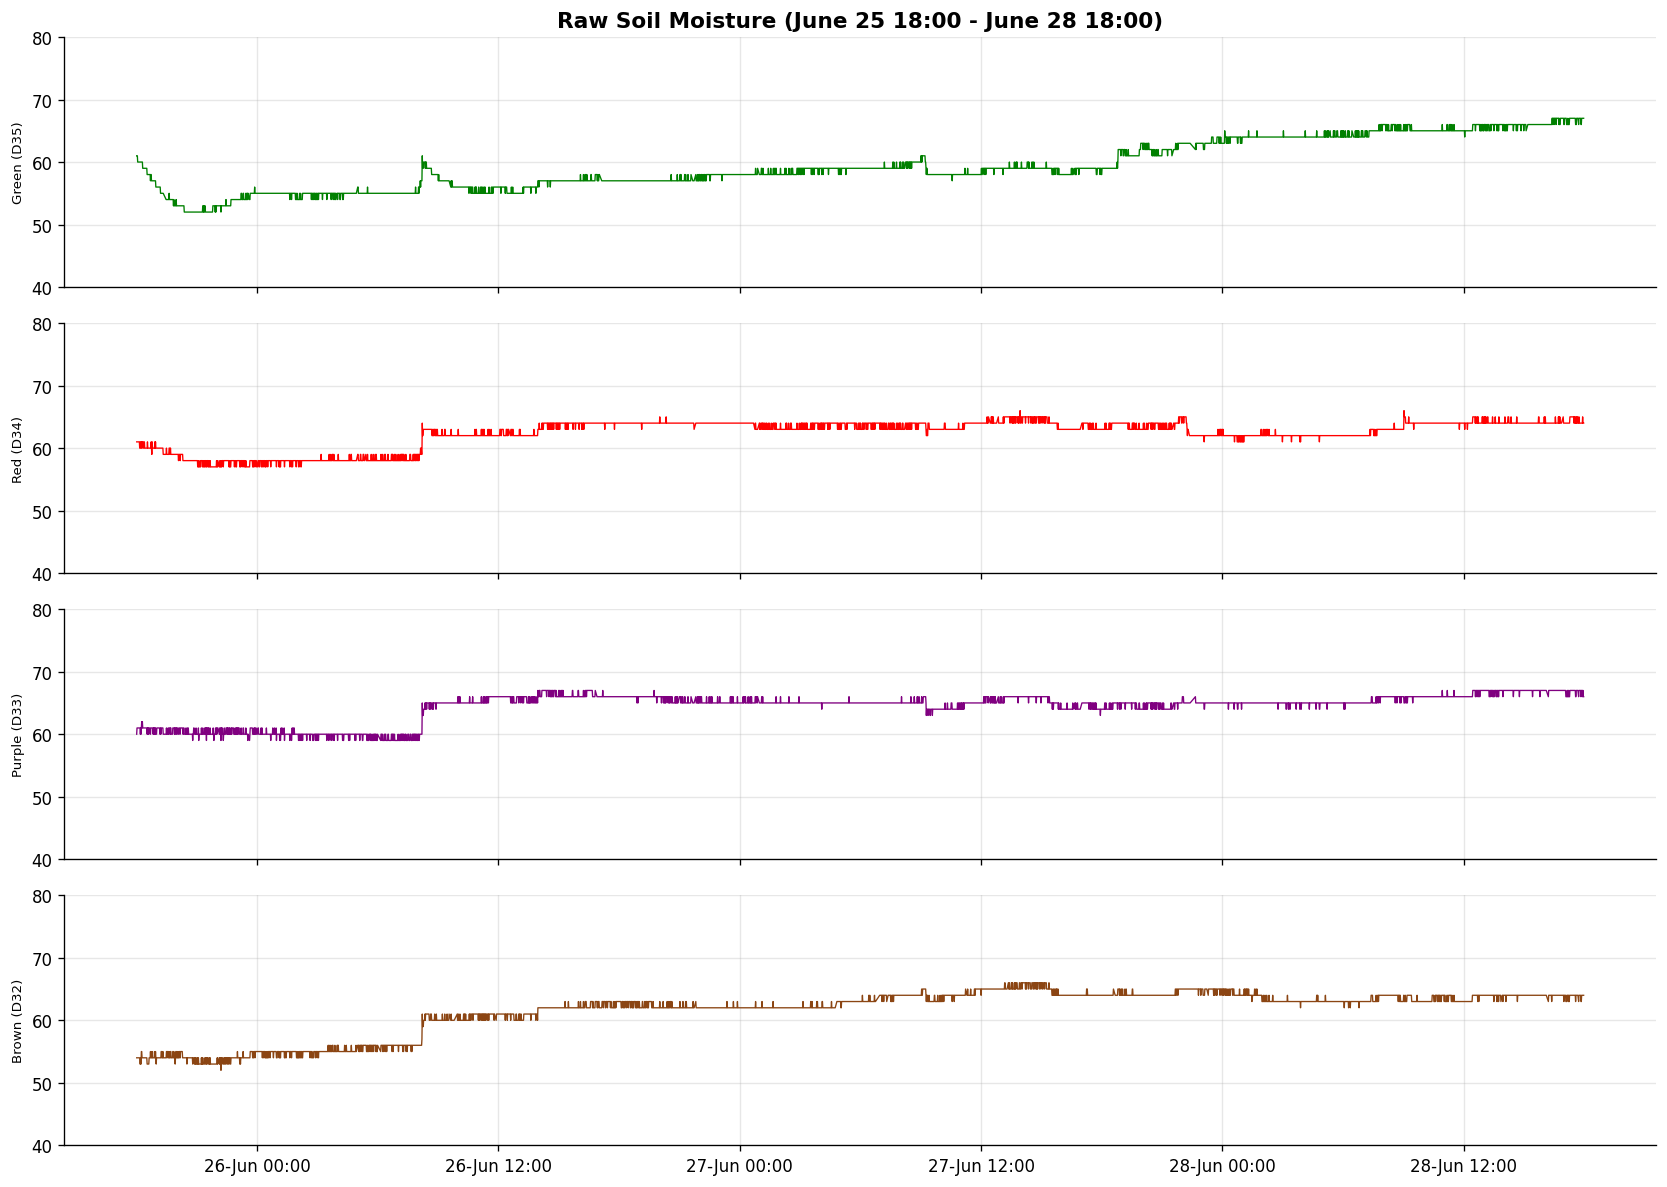

In [35]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('tab10')

# --- Start of Data Loading ---
JSON_PATH = r"/content/agriculture-esp32 monday.json"

with open(JSON_PATH, 'r') as f:
    raw_data = json.load(f)

records = []
ag_data = raw_data['agriculture_dataset']

for month_key, month_val in ag_data.items():
    for day_key, day_val in month_val.items():
        for time_key, entry in day_val.items():
            soil = entry.get('soil', {})
            row = {
                'recorded_time': pd.to_datetime(entry['recorded_time']),
                'sensor_3': soil.get('3_Red_D34'),
                'sensor_4': soil.get('4_Green_D35'),
                'sensor_5': soil.get('5_Black_D32'),
                'sensor_6': soil.get('6_Purple_D33'),
            }
            records.append(row)

df_raw = pd.DataFrame(records)
df_raw.sort_values('recorded_time', inplace=True)
df_raw.set_index('recorded_time', inplace=True)

# --- GLOBAL TIME FILTER: June 25 18:00 to June 28 18:00 ---
start_limit = pd.to_datetime('2026-06-25 18:00:00')
end_limit = pd.to_datetime('2026-06-28 18:00:00')
df_raw = df_raw.loc[start_limit:end_limit].copy()
df_raw.reset_index(inplace=True)

SENSOR_COLS   = ['sensor_4','sensor_3','sensor_6','sensor_5']
SENSOR_LABELS = ['Green (D35)','Red (D34)','Purple (D33)','Brown (D32)']

# --- Plot Raw Data ---
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
colors = ['green', 'red', 'purple', 'saddlebrown']

for i, (col, label) in enumerate(zip(SENSOR_COLS, SENSOR_LABELS)):
    axes[i].plot(df_raw['recorded_time'], df_raw[col], color=colors[i], linewidth=0.8)
    axes[i].set_ylabel(label, fontsize=8)
    axes[i].set_ylim(40, 80)
    axes[i].grid(True, alpha=0.3)

axes[0].set_title('Raw Soil Moisture (June 25 18:00 - June 28 18:00)', fontsize=13, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
fig.tight_layout()
plt.show()


### Pembersihan Data & Smoothing (Moving Average)

In [37]:
orig_sensor_cols = ['sensor_4', 'sensor_3', 'sensor_6', 'sensor_5']
english_sensor_names = ['sensor_green', 'sensor_red', 'sensor_purple', 'sensor_brown']

df_analysis = df_raw.copy()
if 'recorded_time' in df_analysis.columns:
    df_analysis.set_index('recorded_time', inplace=True)

# FILTER WAKTU (Sekali lagi untuk dataframe baru)
start_time = pd.to_datetime('2026-06-25 18:00:00')
end_time   = pd.to_datetime('2026-06-28 18:00:00')
df_filtered = df_analysis.loc[start_time:end_time].copy()
df_final = pd.DataFrame(index=df_filtered.index)

# TAHAP 1: MISSING VALUE HANDLING
for orig_col, new_name in zip(orig_sensor_cols, english_sensor_names):
    handled_data = df_filtered[orig_col].interpolate(method='linear').bfill().ffill()
    df_final[f'raw_{new_name}'] = handled_data

# TAHAP 2: MOVING AVERAGE (Smoothing)
for new_name in english_sensor_names:
    df_final[f'smooth_{new_name}'] = df_final[f'raw_{new_name}'].rolling(window=5, min_periods=1).mean()


### Plot Khusus Data After Smoothing (Grafik Baru)

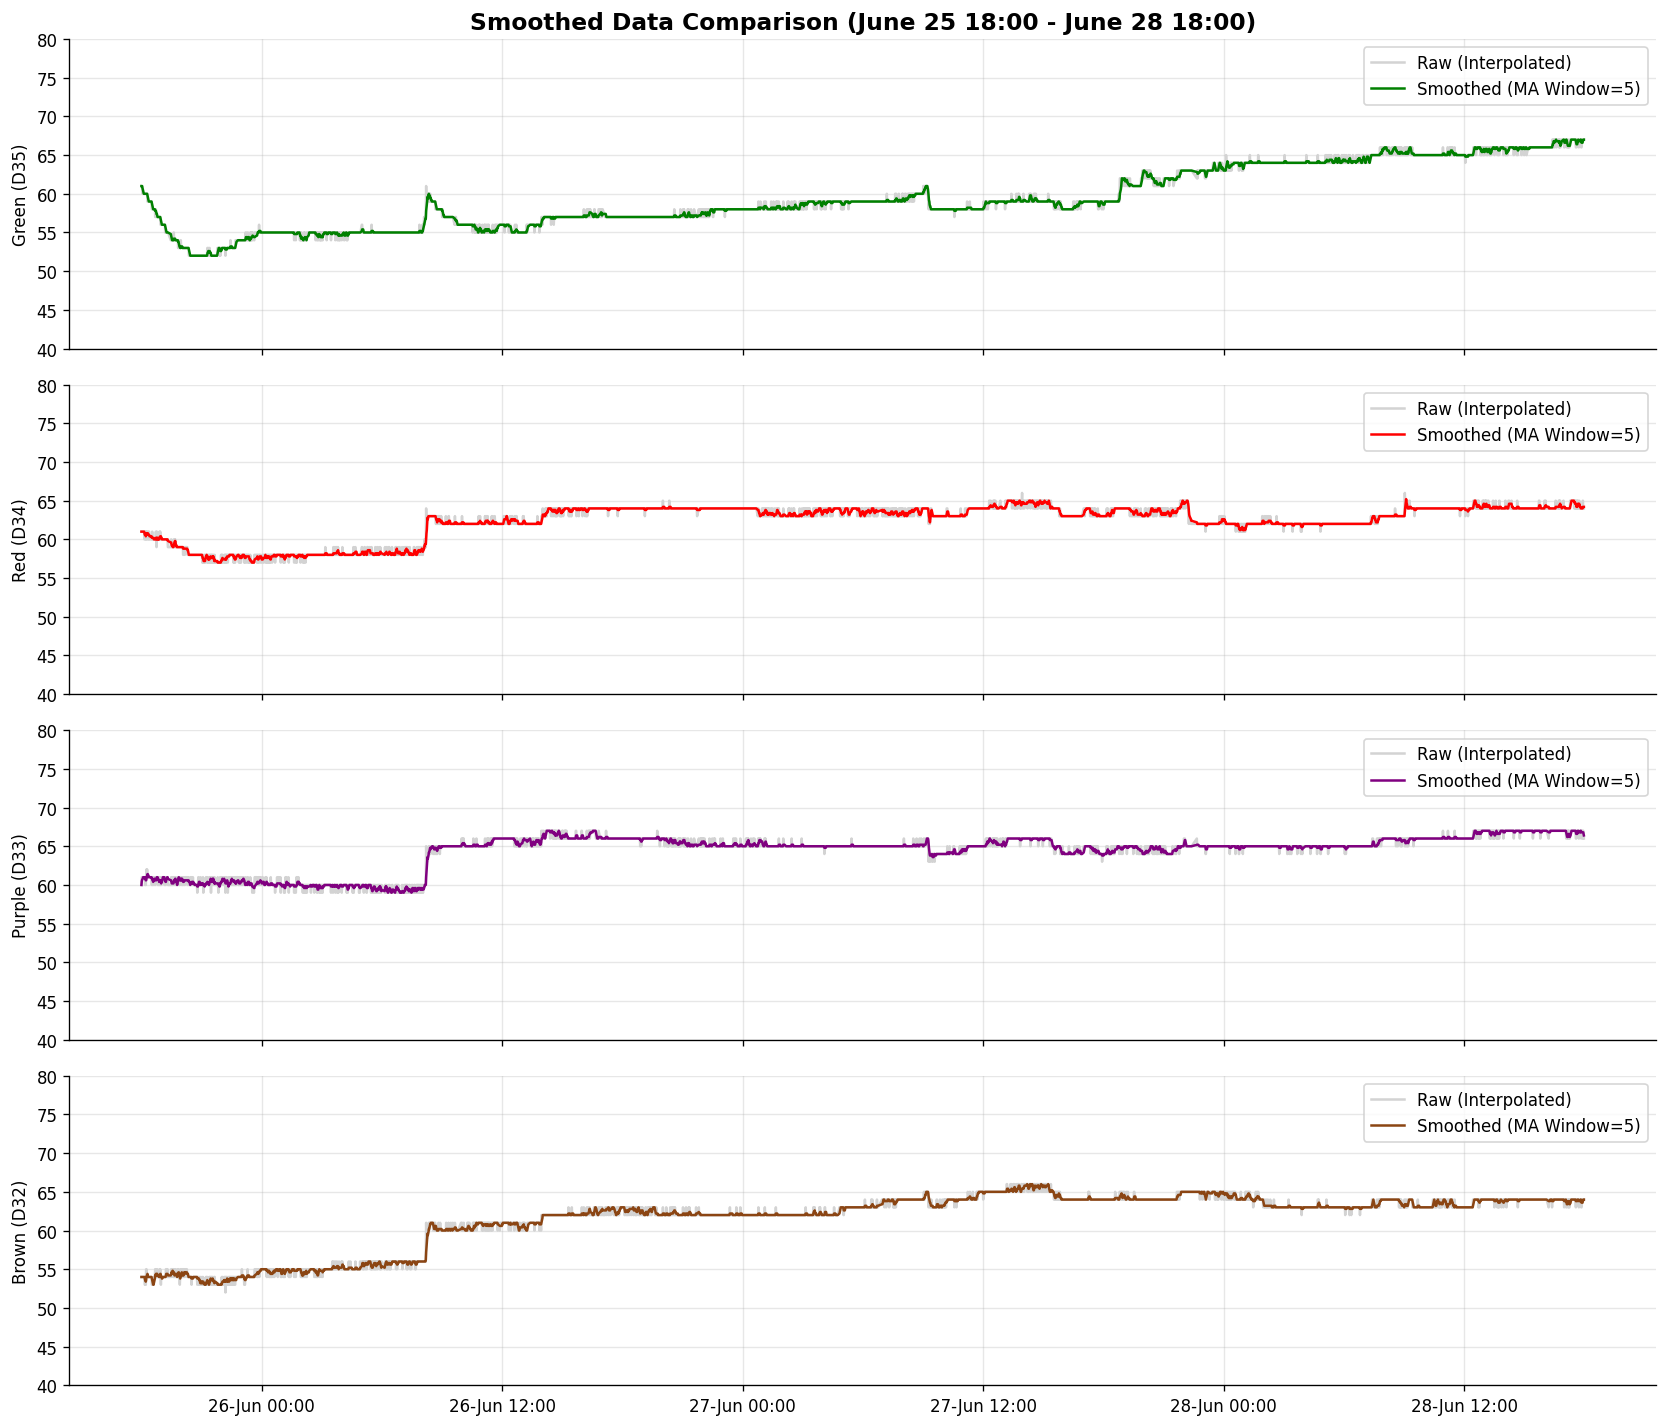

In [38]:
# Visualize Raw vs Smoothed Data (Mirip dengan plot Raw)
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
colors = ['green', 'red', 'purple', 'saddlebrown']
labels = ['Green (D35)', 'Red (D34)', 'Purple (D33)', 'Brown (D32)']

for i, (sensor, color, label) in enumerate(zip(english_sensor_names, colors, labels)):
    axes[i].plot(df_final.index, df_final[f'raw_{sensor}'], color='lightgray', label='Raw (Interpolated)', linewidth=1.5)
    axes[i].plot(df_final.index, df_final[f'smooth_{sensor}'], color=color, label='Smoothed (MA Window=5)', linewidth=1.5)
    axes[i].set_ylabel(label, fontsize=10)
    axes[i].set_ylim(40, 80)
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[0].set_title('Smoothed Data Comparison (June 25 18:00 - June 28 18:00)', fontsize=14, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
fig.tight_layout()
plt.show()


Injeksi Anomali Sintetis & Export Tabel Data

In [39]:
# TAHAP 3: SYNTHETIC ANOMALY INJECTION
def inject_identifications(series, anomaly_ratio=0.05):
    n = len(series)
    is_anomaly = np.zeros(n, dtype=int)
    anomaly_type = np.zeros(n, dtype=int)
    series_injected = series.copy()

    spike_d = 25.0; drop_d = 25.0; drift_a = 2.0; drift_len = 10; stuck_len = 8
    points_per = 1 + 1 + drift_len + stuck_len
    n_per_type = max(1, int(n * anomaly_ratio / points_per))

    for _ in range(n_per_type): # 1. SPIKE
        p = np.random.randint(0, n)
        series_injected.iloc[p] += spike_d
        is_anomaly[p]=1; anomaly_type[p]=1
    for _ in range(n_per_type): # 2. DRIFT
        t0 = np.random.randint(0, max(1, n - drift_len))
        for dt in range(min(drift_len, n - t0)):
            series_injected.iloc[t0 + dt] += drift_a * dt
            is_anomaly[t0 + dt] = 1; anomaly_type[t0 + dt] = 2
    for _ in range(n_per_type): # 3. DROP
        p = np.random.randint(0, n)
        series_injected.iloc[p] -= drop_d
        is_anomaly[p]=1; anomaly_type[p]=3
    for _ in range(n_per_type): # 4. STUCK
        t0 = np.random.randint(0, max(1, n - stuck_len))
        stuck_val = series_injected.iloc[t0]
        for dt in range(min(stuck_len, n - t0)):
            series_injected.iloc[t0 + dt] = stuck_val
            is_anomaly[t0 + dt] = 1; anomaly_type[t0 + dt] = 4
    return series_injected, is_anomaly, anomaly_type

for new_name in english_sensor_names:
    injected_data, is_anom, anom_type = inject_identifications(df_final[f'smooth_{new_name}'])
    df_final[f'smooth_{new_name}'] = injected_data
    df_final[f'is_anomaly_{new_name}'] = is_anom
    df_final[f'anomaly_type_{new_name}'] = anom_type

# EXPORT TO CSV
csv_filename = 'anomaly_analysis_sensor.csv'
df_final.to_csv(csv_filename, index=True)
display(df_final.head(5))


,raw_sensor_green,raw_sensor_red,raw_sensor_purple,raw_sensor_brown,smooth_sensor_green,smooth_sensor_red,smooth_sensor_purple,smooth_sensor_brown,is_anomaly_sensor_green,anomaly_type_sensor_green,is_anomaly_sensor_red,anomaly_type_sensor_red,is_anomaly_sensor_purple,anomaly_type_sensor_purple,is_anomaly_sensor_brown,anomaly_type_sensor_brown
recorded_time,,,,,,,,,,,,,,,,
2026-06-25 18:00:29,61,61,60,54,61.00,61.0,60.000000,54.0,0,0,0,0,0,0,0,0
2026-06-25 18:01:29,61,61,61,54,61.00,61.0,60.500000,54.0,0,0,0,0,0,0,0,0
2026-06-25 18:02:29,61,61,61,54,61.00,61.0,60.666667,54.0,0,0,0,0,0,0,0,0
2026-06-25 18:03:29,60,61,61,54,60.75,61.0,60.750000,54.0,0,0,0,0,0,0,0,0
2026-06-25 18:04:29,60,61,61,54,60.60,61.0,60.800000,54.0,0,0,0,0,0,0,0,0


### Plot Data dengan Sintetis Anomali

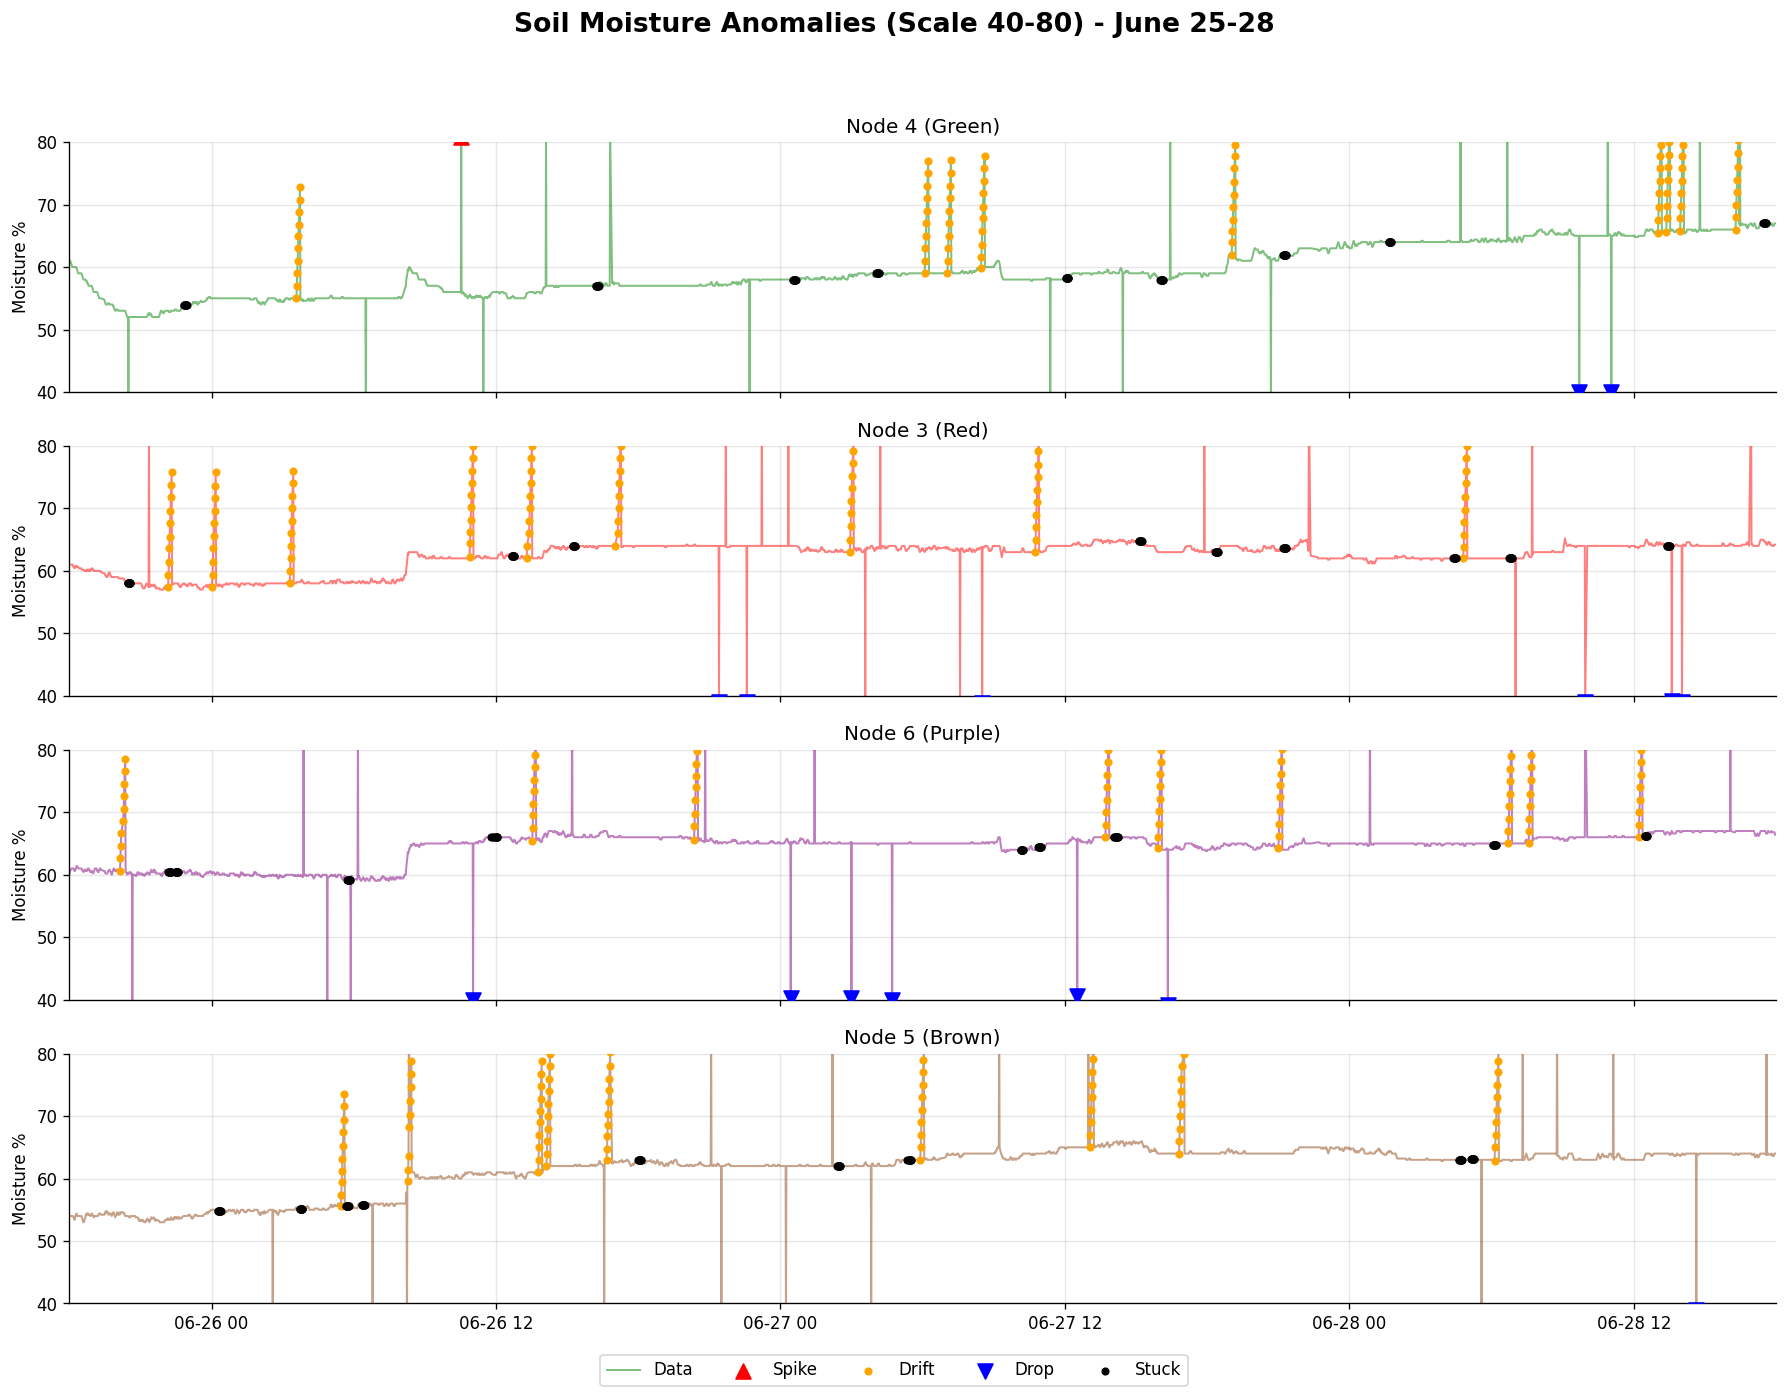

In [40]:
sensors = ['sensor_green', 'sensor_red', 'sensor_purple', 'sensor_brown']
line_colors = ['green', 'red', 'purple', 'saddlebrown']
sensor_titles = ['Node 4 (Green)', 'Node 3 (Red)', 'Node 6 (Purple)', 'Node 5 (Brown)']

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
fig.suptitle('Soil Moisture Anomalies (Scale 40-80) - June 25-28', fontsize=16, fontweight='bold')

plot_start = pd.to_datetime('2026-06-25 18:00:00')
plot_end = pd.to_datetime('2026-06-28 18:00:00')

for i, sensor in enumerate(sensors):
    ax = axes[i]
    times = df_final.index
    vals = df_final[f'smooth_{sensor}'].values
    anom_types = df_final[f'anomaly_type_{sensor}'].values

    ax.plot(times, vals, color=line_colors[i], label='Data', linewidth=1.2, alpha=0.5)

    idx_s = np.where(anom_types == 1)[0]
    ax.scatter(times[idx_s], vals[idx_s], color='red', marker='^', s=80, label='Spike', zorder=5)
    idx_dr = np.where(anom_types == 2)[0]
    ax.scatter(times[idx_dr], vals[idx_dr], color='orange', s=15, label='Drift', zorder=4)
    idx_d = np.where(anom_types == 3)[0]
    ax.scatter(times[idx_d], vals[idx_d], color='blue', marker='v', s=80, label='Drop', zorder=5)
    idx_st = np.where(anom_types == 4)[0]
    ax.scatter(times[idx_st], vals[idx_st], color='black', s=15, label='Stuck', zorder=4)

    ax.set_ylim(40, 80)
    ax.set_xlim(plot_start, plot_end)
    ax.set_title(sensor_titles[i])
    ax.set_ylabel('Moisture %')
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, 0.02))
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


### Hampel Filter & Isolation Forest Models



In [41]:
from sklearn.ensemble import IsolationForest

def hampel_filter(series, window_size=5, n_sigmas=3):
    rolling_median = series.rolling(window=window_size, center=True).median()
    mad = series.rolling(window=window_size, center=True).apply(lambda x: np.median(np.abs(x - np.median(x))), raw=True)
    upper_bound = rolling_median + (n_sigmas * 1.4826 * mad)
    lower_bound = rolling_median - (n_sigmas * 1.4826 * mad)
    anomalies = ((series > upper_bound) | (series < lower_bound)).astype(int)
    return anomalies.fillna(0).astype(int)

for sensor in english_sensor_names:
    col_name = f'smooth_{sensor}'

    # Hampel Filter
    df_final[f'hampel_pred_{sensor}'] = hampel_filter(df_final[col_name], window_size=10, n_sigmas=3)

    # Isolation Forest
    iso_forest = IsolationForest(contamination=0.05, random_state=42)
    preds = iso_forest.fit_predict(df_final[[col_name]])
    df_final[f'iforest_pred_{sensor}'] = np.where(preds == -1, 1, 0)


### Visualisasi Deteksi Hampel Filter

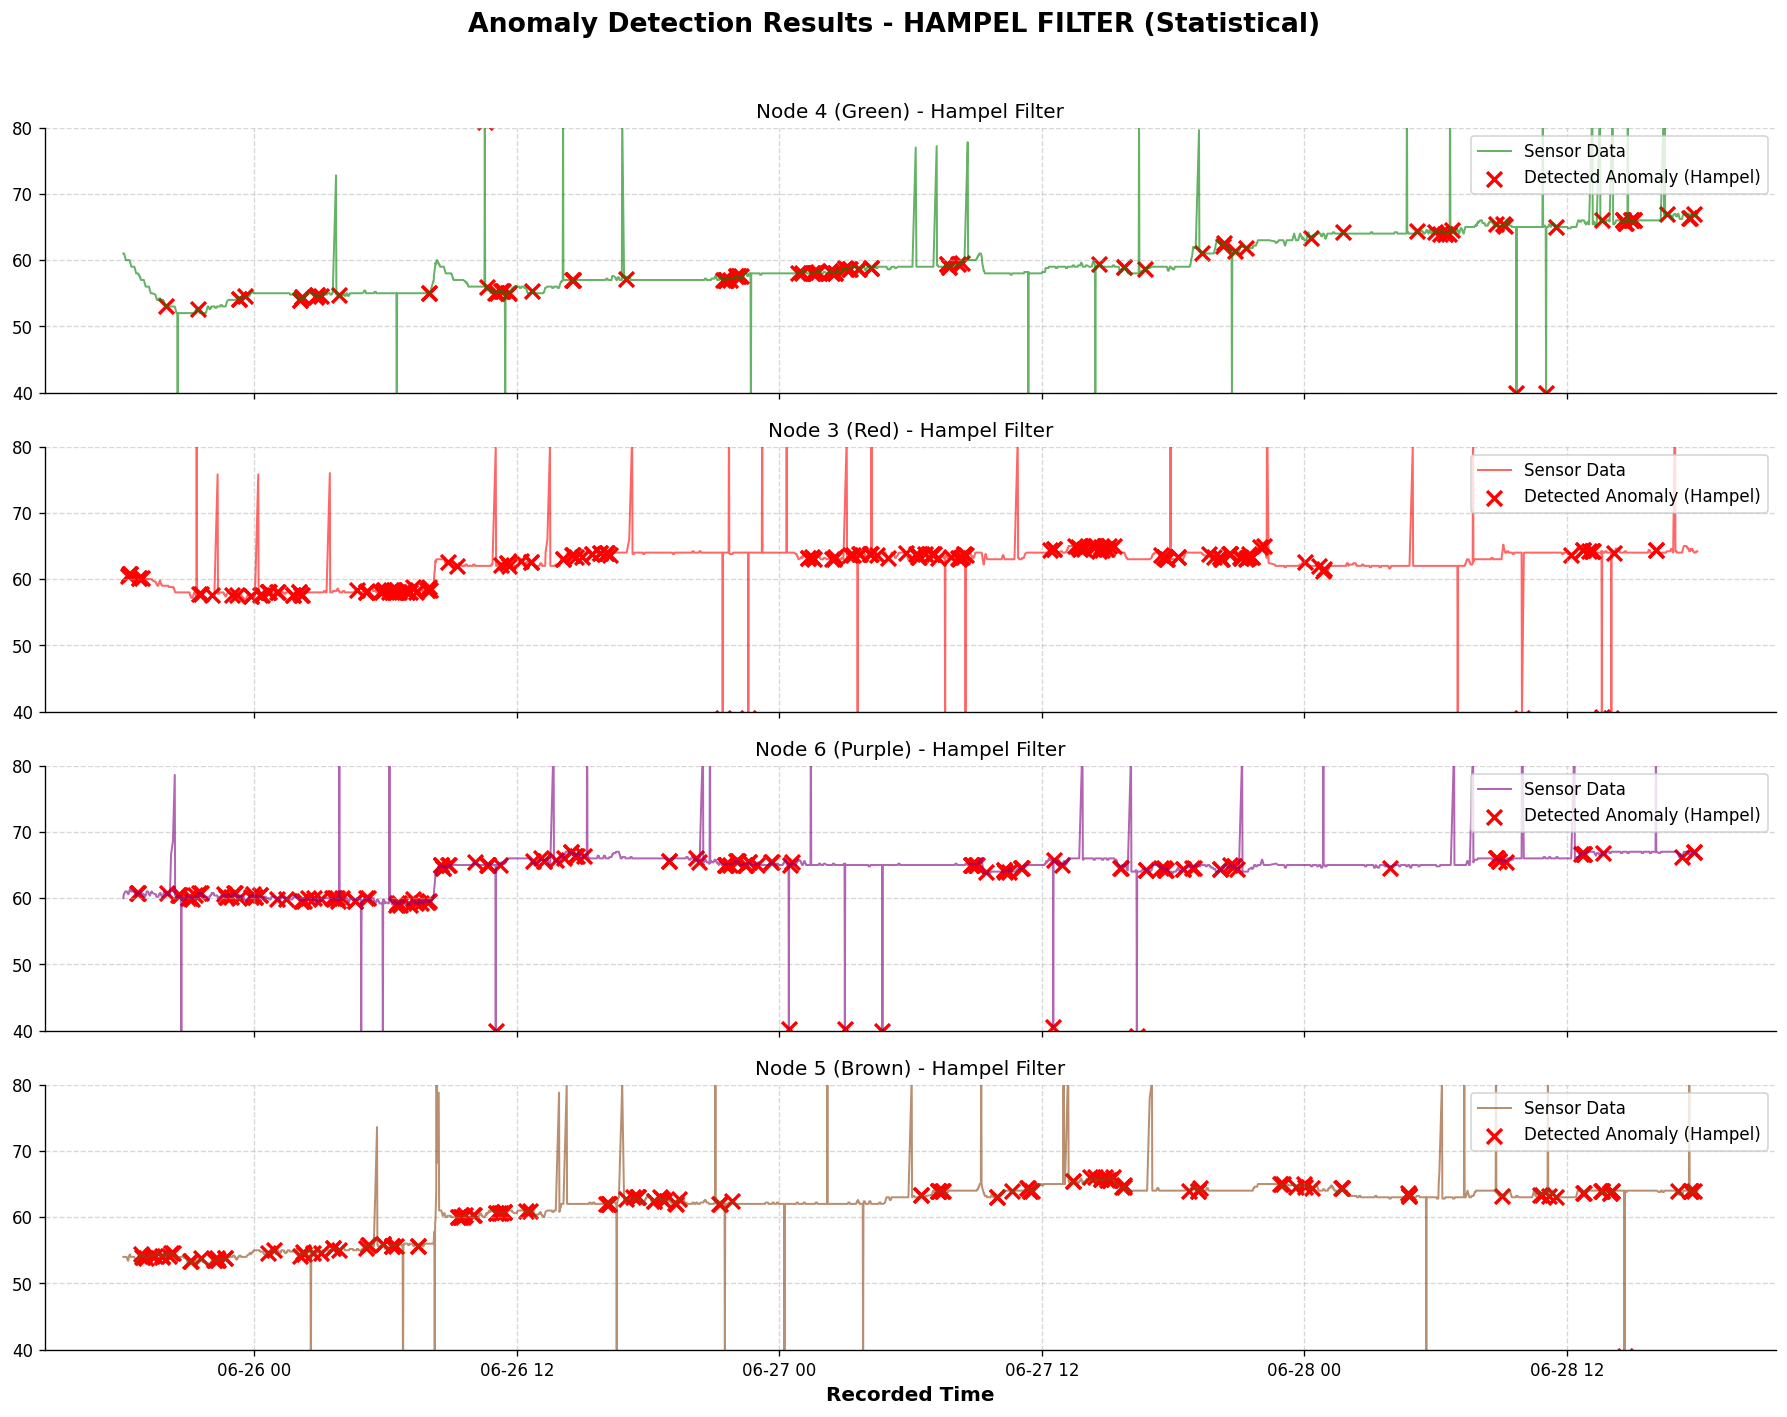

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

line_colors = ['green', 'red', 'purple', 'saddlebrown']
sensor_titles = ['Node 4 (Green)', 'Node 3 (Red)', 'Node 6 (Purple)', 'Node 5 (Brown)']

# GRAPH 1: HAMPEL FILTER DETECTIONS
fig1, axes1 = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
fig1.suptitle('Anomaly Detection Results - HAMPEL FILTER (Statistical)', fontsize=16, fontweight='bold')

for i, sensor in enumerate(english_sensor_names):
    ax = axes1[i]
    times = df_final.index
    vals = df_final[f'smooth_{sensor}'].values
    preds = df_final[f'hampel_pred_{sensor}'].values

    ax.plot(times, vals, color=line_colors[i], label='Sensor Data', linewidth=1.2, alpha=0.6)

    idx_anom = np.where(preds == 1)[0]
    if len(idx_anom) > 0:
        ax.scatter(times[idx_anom], vals[idx_anom], color='red', marker='x', s=80, linewidth=2, label='Detected Anomaly (Hampel)')

    ax.set_ylim(40, 80)
    ax.set_title(f"{sensor_titles[i]} - Hampel Filter")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

plt.xlabel('Recorded Time', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



###  Visualisasi Deteksi Isolation Forest


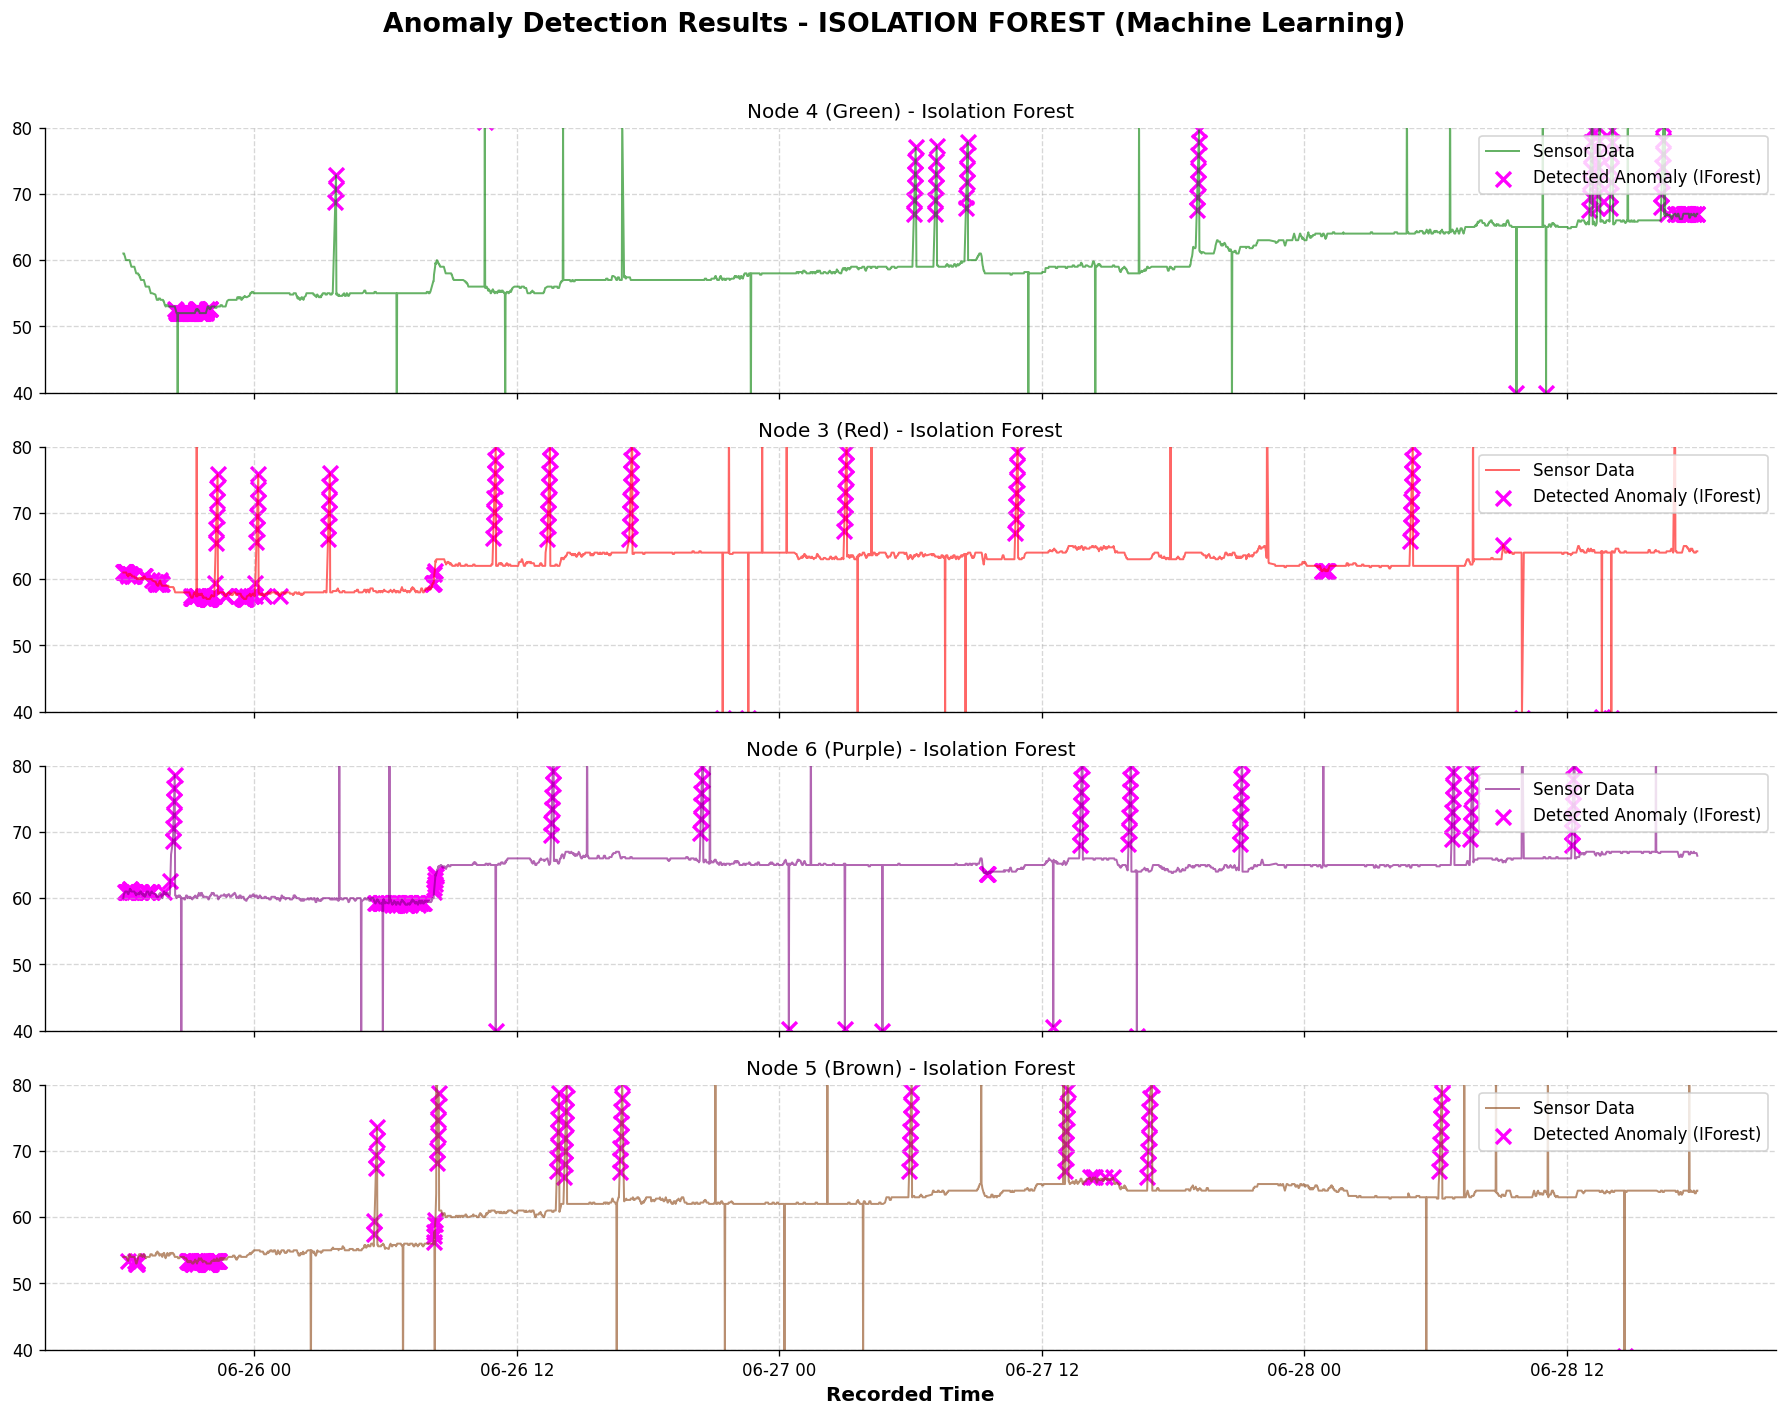

In [43]:
# GRAPH 2: ISOLATION FOREST DETECTIONS
fig2, axes2 = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
fig2.suptitle('Anomaly Detection Results - ISOLATION FOREST (Machine Learning)', fontsize=16, fontweight='bold')

for i, sensor in enumerate(english_sensor_names):
    ax = axes2[i]
    times = df_final.index
    vals = df_final[f'smooth_{sensor}'].values
    preds = df_final[f'iforest_pred_{sensor}'].values

    ax.plot(times, vals, color=line_colors[i], label='Sensor Data', linewidth=1.2, alpha=0.6)

    idx_anom = np.where(preds == 1)[0]
    if len(idx_anom) > 0:
        ax.scatter(times[idx_anom], vals[idx_anom], color='magenta', marker='x', s=80, linewidth=2, label='Detected Anomaly (IForest)')

    ax.set_ylim(40, 80)
    ax.set_title(f"{sensor_titles[i]} - Isolation Forest")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

plt.xlabel('Recorded Time', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### Performance Evaluation & Grafik Batang (Bar Chart)

=== MODEL COMPARISON EVALUATION RESULTS ===


,Sensor,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,sensor_green,Hampel Filter,0.1452,0.1006,0.1188,0.5364,0.0550
1,sensor_green,Isolation Forest,0.3249,0.3575,0.3404,0.6451,0.3892
2,sensor_red,Hampel Filter,0.0933,0.1011,0.0970,0.5276,0.0496
3,sensor_red,Isolation Forest,0.5489,0.5674,0.5580,0.7916,0.6074
4,sensor_purple,Hampel Filter,0.0966,0.0950,0.0958,0.5266,0.0498
5,sensor_purple,Isolation Forest,0.4943,0.4804,0.4873,0.7818,0.5174
6,sensor_brown,Hampel Filter,0.1024,0.0950,0.0986,0.5279,0.0504
7,sensor_brown,Isolation Forest,0.5230,0.5084,0.5156,0.7792,0.5302


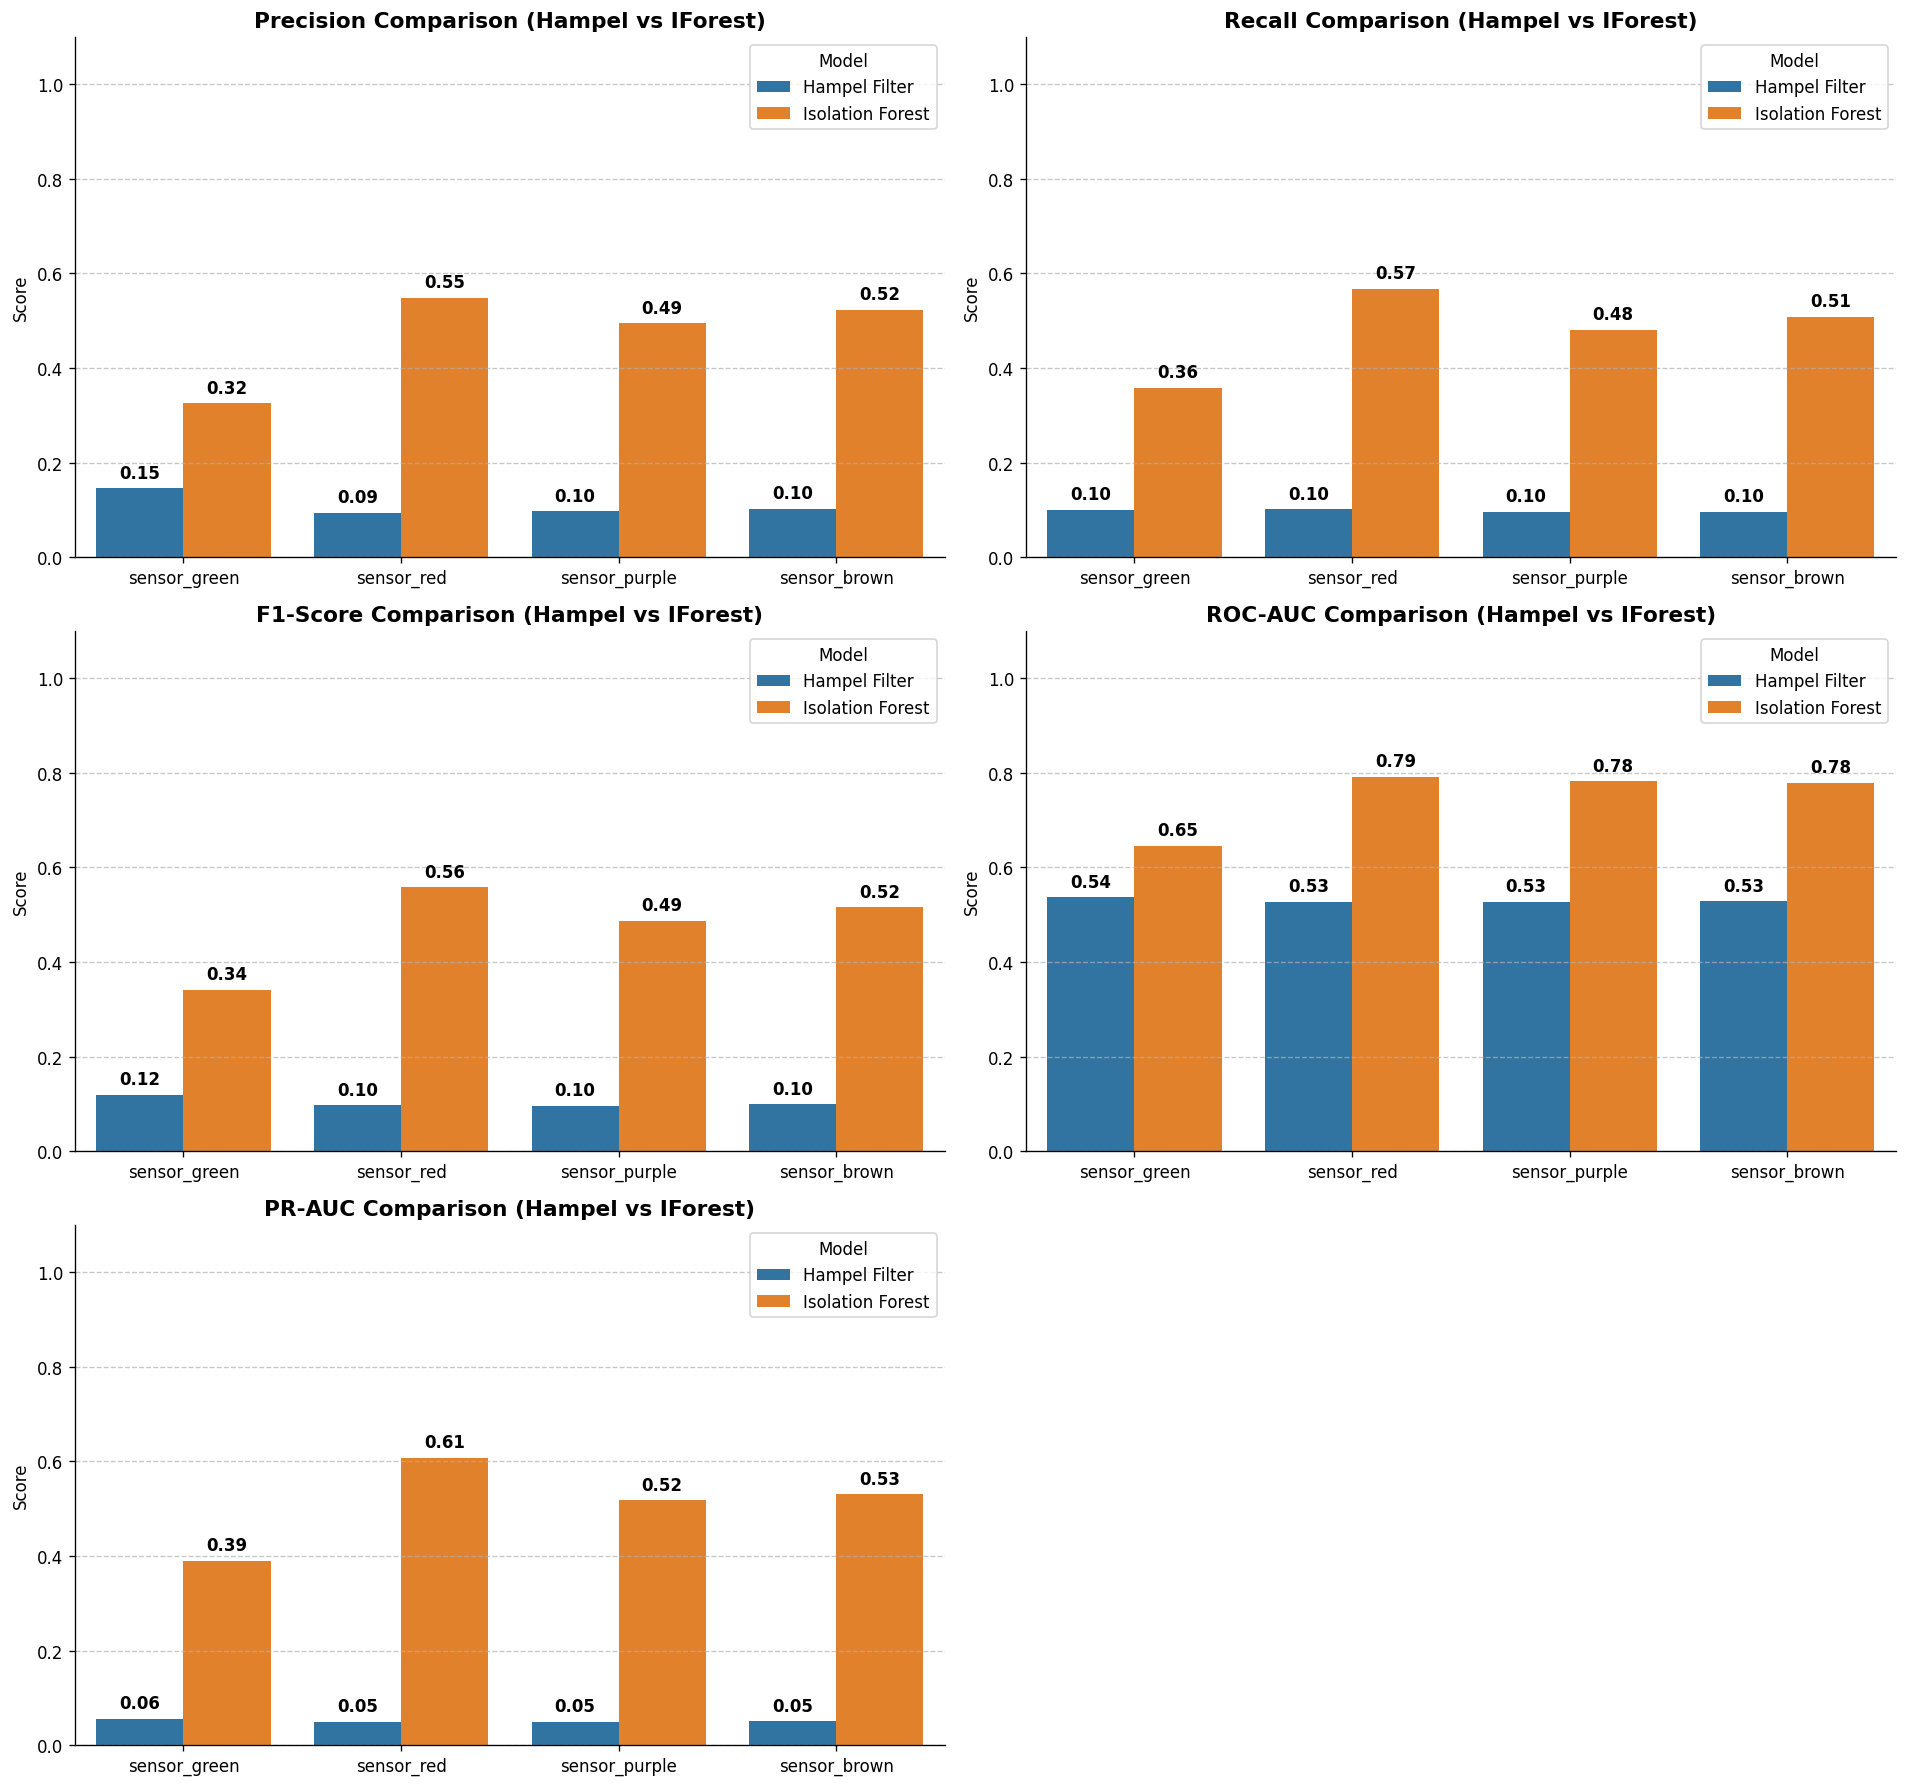

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# STEP 5: PERFORMANCE EVALUATION (Calculating Metrics)

metrics_records = []

for sensor in english_sensor_names:
    y_true = df_final[f'is_anomaly_{sensor}']

    for model_name, pred_col in [('Hampel Filter', f'hampel_pred_{sensor}'),
                                 ('Isolation Forest', f'iforest_pred_{sensor}')]:

        y_pred = df_final[pred_col]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if model_name == 'Isolation Forest':
            iso_forest = IsolationForest(contamination=0.05, random_state=42)
            iso_forest.fit(df_final[[f'smooth_{sensor}']])
            y_scores = -1 * iso_forest.decision_function(df_final[[f'smooth_{sensor}']])
        else:
            y_scores = y_pred

        roc_auc = roc_auc_score(y_true, y_scores)
        pr_auc = average_precision_score(y_true, y_scores)

        metrics_records.append({
            'Sensor': sensor,
            'Model': model_name,
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1-Score': round(f1, 4),
            'ROC-AUC': round(roc_auc, 4),
            'PR-AUC': round(pr_auc, 4)
        })

df_metrics = pd.DataFrame(metrics_records)
print("=== MODEL COMPARISON EVALUATION RESULTS ===")
display(df_metrics)

# GRAPH 3: PERFORMANCE EVALUATION (Bar Charts)
fig3, axes3 = plt.subplots(3, 2, figsize=(16, 15))
axes3 = axes3.flatten()

metrics_list = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
model_colors = ['#1f77b4', '#ff7f0e']

for i, metric in enumerate(metrics_list):
    ax = axes3[i]
    sns.barplot(data=df_metrics, x='Sensor', y=metric, hue='Model', ax=ax, palette=model_colors)

    ax.set_title(f'{metric} Comparison (Hampel vs IForest)', fontweight='bold', fontsize=13)
    ax.set_ylim(0, 1.1)
    ax.set_xlabel('')
    ax.set_ylabel('Score')
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(f"{height:.2f}",
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', xytext=(0, 4),
                        textcoords='offset points', fontsize=10, fontweight='bold')

fig3.delaxes(axes3[5])
plt.tight_layout()
plt.show()
